In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sbn

In [5]:
df = pd.read_csv("Datasets/c4_epa_air_quality.csv")


In [6]:
df.head()


,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3


In [7]:
df.describe()


,Unnamed: 0,arithmetic_mean,aqi
count,260.000000,260.000000,260.000000
mean,129.500000,0.403169,6.757692
std,75.199734,0.317902,7.061707
min,0.000000,0.000000,0.000000
25%,64.750000,0.200000,2.000000
50%,129.500000,0.276315,5.000000
75%,194.250000,0.516009,9.000000
max,259.000000,1.921053,50.000000


In [8]:
df.shape


(260, 10)

In [10]:
df.dtypes

Unnamed: 0            int64
date_local              str
state_name              str
county_name             str
city_name               str
local_site_name         str
parameter_name          str
units_of_measure        str
arithmetic_mean     float64
aqi                   int64
dtype: object

In [13]:
s = [2, 2, 4, 7, 10]

np.mean(s)

np.float64(5.0)

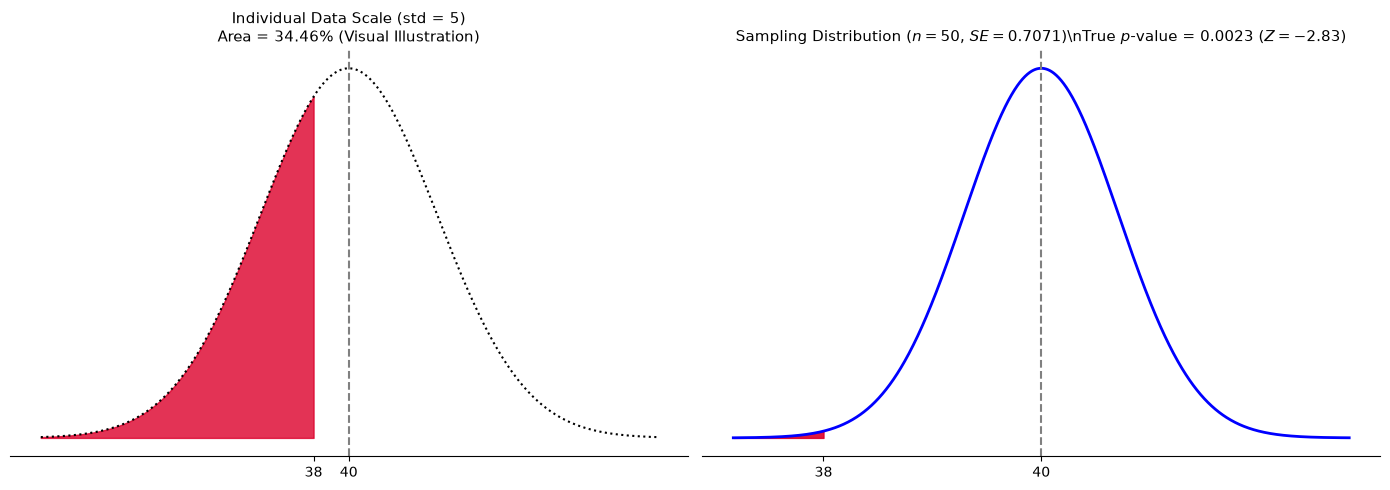

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

mean = 40
sigma = 5
n = 50
se = sigma / np.sqrt(n)  # 0.7071

# Calculate Z-score and actual p-value for the sample mean
z_score = (38 - mean) / se
p_value = norm.cdf(38, mean, se)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Individual Deliveries (Course Visual Style, std = 5) ---
x1 = np.linspace(mean - 3.5 * sigma, mean + 3.5 * sigma, 1000)
y1 = norm.pdf(x1, mean, sigma)

ax1.plot(x1, y1, 'k:', label=rf'Individual $X \sim N(40, 5^2)$')
x1_fill = np.linspace(mean - 3.5 * sigma, 38, 500)
ax1.fill_between(x1_fill, norm.pdf(x1_fill, mean, sigma), color='#dc002b', alpha=0.8)
ax1.axvline(40, color='gray', linestyle='--')
ax1.set_title(f"Individual Data Scale (std = {sigma})\nArea = 34.46% (Visual Illustration)", fontsize=11)
ax1.set_xticks([38, 40])

# --- Plot 2: Sampling Distribution of Mean (n = 50, SE = 0.7071) ---
x2 = np.linspace(mean - 4 * se, mean + 4 * se, 1000)
y2 = norm.pdf(x2, mean, se)

ax2.plot(x2, y2, 'b-', linewidth=2, label=rf'Sample Mean $\bar{{X}} \sim N(40, 0.7071^2)$')
x2_fill = np.linspace(mean - 4 * se, 38, 500)
ax2.fill_between(x2_fill, norm.pdf(x2_fill, mean, se), color='#dc002b', alpha=0.9)
ax2.axvline(40, color='gray', linestyle='--')
ax2.set_title(rf"Sampling Distribution ($n=50$, $SE=0.7071$)\nTrue $p$-value = {p_value:.4f} ($Z = -2.83$)", fontsize=11)
ax2.set_xticks([38, 40])

for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])

plt.tight_layout()
plt.show()